In [2]:
pip install numpy pandas scipy matplotlib

In [3]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter
import matplotlib.pyplot as plt

# ── 1. Загрузка данных ─────────────────────────────────────
df = pd.read_csv('data4ch_0_7.xls', header=None)   # ваш файл
time = df.iloc[:, 0].values
ppg_chest_raw = df.iloc[:, 1].values
ppg_arm_raw   = df.iloc[:, 2].values
ecg_raw       = df.iloc[:, 4].values

fs = 1.0 / np.mean(np.diff(time))
print(f"Частота дискретизации: {fs:.2f} Гц")



import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Исходные сырые данные
time_raw = df.iloc[:, 0].values
ch1_raw = df.iloc[:, 1].values   # ФПГ грудь
ch2_raw = df.iloc[:, 2].values   # ФПГ рука
ch4_raw = df.iloc[:, 4].values   # ЭКГ

fig_raw = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=('Канал 1 — ФПГ грудь (сырой)',
                    'Канал 2 — ФПГ рука (сырой)',
                    'Канал 4 — ЭКГ (сырой)')
)

fig_raw.add_trace(go.Scattergl(
    x=time_raw, y=ch1_raw, mode='lines', name='ФПГ грудь', line=dict(color='green', width=0.8)
), row=1, col=1)

fig_raw.add_trace(go.Scattergl(
    x=time_raw, y=ch2_raw, mode='lines', name='ФПГ рука', line=dict(color='purple', width=0.8)
), row=2, col=1)

fig_raw.add_trace(go.Scattergl(
    x=time_raw, y=ch4_raw, mode='lines', name='ЭКГ', line=dict(color='blue', width=0.8)
), row=3, col=1)

fig_raw.update_xaxes(title_text="Время (с)", row=3, col=1)
fig_raw.update_yaxes(title_text="АЦП", row=1, col=1)
fig_raw.update_yaxes(title_text="АЦП", row=2, col=1)
fig_raw.update_yaxes(title_text="АЦП", row=3, col=1)

fig_raw.update_layout(
    height=700,
    showlegend=True,
    title_text="Исходные сигналы (без фильтрации)",
    hovermode='x unified'
)

# Показываем первые 30 секунд и добавляем ползунок
fig_raw.update_xaxes(range=[0, 30])
fig_raw.update_xaxes(rangeslider=dict(visible=True), row=3, col=1)

fig_raw.show()




from scipy.interpolate import interp1d

def find_foot_in_segment(ppg_seg, fs, interp_factor=4):
    """
    Ищет точку «ноги» (начала подъёма) внутри одного сегмента ФПГ.
    Для повышения точности при низкой fs сначала интерполирует сигнал
    в interp_factor раз, затем ищет минимум перед максимальной производной.
    Возвращает индекс (в исходной шкале) или None.
    """
    if len(ppg_seg) < 5:
        return None

    # Интерполяция для увеличения временного разрешения
    t_orig = np.arange(len(ppg_seg)) / fs
    fs_new = fs * interp_factor
    t_new = np.linspace(0, t_orig[-1], int(len(ppg_seg) * interp_factor))
    f = interp1d(t_orig, ppg_seg, kind='cubic')
    ppg_interp = f(t_new)

    # Производная
    deriv = np.gradient(ppg_interp)
    # Максимум производной (крутой подъём)
    max_deriv_idx = np.argmax(deriv)
    # Минимум перед этой точкой (в пределах 200 мс назад)
    search_back = int(0.2 * fs_new)
    start = max(0, max_deriv_idx - search_back)
    foot_idx_interp = start + np.argmin(ppg_interp[start:max_deriv_idx])
    # Переводим обратно в индекс исходного сигнала
    foot_time = foot_idx_interp / fs_new
    return foot_time * fs   # примерный индекс, может быть дробным

def ptt_via_xcorr(chest_seg, arm_seg, fs, max_lag_ms=150):
    """Оценка PTT через взаимную корреляцию сегментов."""
    lags_samples = int(max_lag_ms / 1000 * fs)
    c = chest_seg - np.mean(chest_seg)
    a = arm_seg - np.mean(arm_seg)
    corr = np.correlate(a, c, mode='full')
    mid = len(c) - 1
    idx = np.argmax(corr)
    lag = idx - mid
    if abs(lag) > lags_samples:
        return None
    # Проверка на слабую корреляцию
    max_corr = corr[idx] / (np.std(c) * np.std(a) * len(c) + 1e-8)
    if max_corr < 0.3:
        return None
    return lag / fs











# ── 2. Фильтрация ─────────────────────────────────────────
def bandpass(sig, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, sig)

# ---------- Базовые фильтры ----------
def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if high >= 1.0:
        high = 0.99            # защита от превышения Найквиста
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def highpass_filter(data, fs, cutoff=0.5, order=4):
    nyq = 0.5 * fs
    if cutoff / nyq >= 1.0:
        raise ValueError("cutoff слишком высока для данной fs")
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, data)

def lowpass_filter(data, fs, cutoff=15.0, order=4):
    nyq = 0.5 * fs
    if cutoff / nyq >= 1.0:
        cutoff = 0.99 * nyq   # безопасное значение
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)
# ---------- Нормализации ----------
def normalize_zscore(x):
    return (x - x.mean()) / (x.std() + 1e-8)

def normalize_minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

# ---------- Безопасные конвейеры для ЭКГ и ФПГ ----------
def preprocess_ecg_safe(ecg_raw, fs):
    # Полосовая фильтрация: 0.5 Гц – верхняя граница < Nyquist
    nyq = 0.5 * fs
    highcut = min(40.0, nyq * 0.99)   # примерно 12.3 Гц при fs=25
    ecg = bandpass_filter(ecg_raw, fs, lowcut=0.5, highcut=highcut)
    ecg = normalize_zscore(ecg)
    return ecg

from scipy.signal import medfilt

def remove_outliers_median(sig, window=5, thresh_std=4.0):
    """
    Заменяет выбросы медианой скользящего окна.
    Точка считается выбросом, если отклоняется от медианы
    более чем на thresh_std * локальное стандартное отклонение.
    """
    # Медианный фильтр для получения локальной медианы
    local_med = medfilt(sig, kernel_size=window)
    # Локальное стандартное отклонение (на основе отклонений от медианы)
    local_std = np.median(np.abs(sig - local_med)) * 1.4826  # MAD -> Std
    outliers = np.abs(sig - local_med) > (thresh_std * local_std + 1e-8)
    cleaned = sig.copy()
    cleaned[outliers] = local_med[outliers]
    return cleaned

def preprocess_ppg_enhanced(ppg_raw, fs):
    """
    Улучшенная предобработка ФПГ:
      1. Удаление выбросов
      2. Highpass 1.0 Гц (жёсткое убирание дыхания)
      3. Lowpass 10 Гц (сглаживание)
      4. Min‑max нормализация
    """
    # Удаляем выбросы (окно ~ 0.2 сек = 5 отсчётов при 25 Гц)
    ppg_clean = remove_outliers_median(ppg_raw, window=5, thresh_std=4.0)
    # Убираем дрейф (highpass 1 Гц)
    ppg_hp = highpass_filter(ppg_clean, fs, cutoff=1.0)
    # Сглаживаем
    ppg_lp = lowpass_filter(ppg_hp, fs, cutoff=10.0)
    # Нормализуем в [0, 1]
    ppg_norm = normalize_minmax(ppg_lp)
    return ppg_norm

def preprocess_all_enhanced(ch_chest, ch_arm, ch_ecg, fs):
    return {
        "ecg":       preprocess_ecg_safe(ch_ecg, fs),   # без изменений
        "ppg_chest": preprocess_ppg_enhanced(ch_chest, fs),
        "ppg_arm":   preprocess_ppg_enhanced(ch_arm, fs),
    }

#ecg_filt = bandpass(ecg_raw, 0.5, 10, fs)
#ppg_chest_filt = bandpass(ppg_chest_raw, 0.5, 10, fs)
#ppg_arm_filt   = bandpass(ppg_arm_raw, 0.5, 10, fs)

# Нормализация для детекции пиков
# def normalize(sig):
#     return (sig - sig.min()) / (sig.max() - sig.min() + 1e-8)

# ecg = normalize(ecg_filt)
# ppg_chest = normalize(ppg_chest_filt)
# ppg_arm   = normalize(ppg_arm_filt)

signals = preprocess_all_enhanced(
    ch_chest = df.iloc[:, 1].values,
    ch_arm   = df.iloc[:, 2].values,
    ch_ecg   = df.iloc[:, 4].values,
    fs       = fs
)

# Дальше работаете с очищенными сигналами
ecg       = signals['ecg']
ppg_chest = signals['ppg_chest']
ppg_arm   = signals['ppg_arm']




fig_clean = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('ФПГ грудь (очищ.)', 'ФПГ рука (очищ.)')
)
fig_clean.add_trace(go.Scattergl(x=time, y=ppg_chest, name='Грудь'), row=1, col=1)
fig_clean.add_trace(go.Scattergl(x=time, y=ppg_arm,   name='Рука'),  row=2, col=1)
fig_clean.update_xaxes(range=[0, 30], row=2, col=1)
fig_clean.update_xaxes(rangeslider=dict(visible=True), row=2, col=1)
fig_clean.update_layout(height=600, title='Очищенные ФПГ')
fig_clean.show()











# ── 3. Классический детектор R‑пиков (Pan‑Tompkins) ─────
# (код из вашего примера, адаптирован под функцию)
def detect_r_peaks_classical(ecg, fs, min_rr_sec=0.35):
    diff = np.diff(ecg, prepend=ecg[0])
    squared = diff ** 2
    win = max(int(0.15 * fs), 1)
    kernel = np.ones(win) / win
    integrated = np.convolve(squared, kernel, mode='same')
    init_samples = min(int(2 * fs), len(integrated))
    threshold = 0.5 * integrated[:init_samples].mean()
    min_dist = int(min_rr_sec * fs)
    peaks, _ = find_peaks(integrated, height=threshold, distance=min_dist)
    # Уточнение по исходному ЭКГ
    half_win = int(0.02 * fs)
    refined = []
    for p in peaks:
        lo = max(0, p - half_win)
        hi = min(len(ecg), p + half_win + 1)
        refined.append(lo + np.argmax(ecg[lo:hi]))
    return np.array(sorted(set(refined)), dtype=int)

def _auto_invert_if_needed(ecg):
    """Возвращает (ecg_processed, was_inverted)."""
    pos = np.max(ecg) - np.median(ecg)
    neg = np.median(ecg) - np.min(ecg)
    if neg > pos:
        return -ecg, True
    return ecg, False

# ── Метод 1: прямой поиск пиков (теперь ищет R вверх) ──
def detect_r_peaks_direct(ecg, fs, min_rr_sec=0.4, prominence=0.5):
    ecg_inv, inverted = _auto_invert_if_needed(ecg)
    if inverted:
        print("⚠️  ЭКГ инвертирована, работаю с перевёрнутым сигналом")
    win = max(3, int(0.08 * fs) | 1)
    ecg_smooth = savgol_filter(ecg_inv, window_length=win, polyorder=2)
    min_dist = int(min_rr_sec * fs)
    peaks, _ = find_peaks(ecg_smooth, distance=min_dist, prominence=prominence)
    refined = []
    for p in peaks:
        lo = max(0, p - 1)
        hi = min(len(ecg_inv), p + 2)
        refined.append(lo + np.argmax(ecg_inv[lo:hi]))
    return np.array(sorted(set(refined)), dtype=int)

# ── Метод 2: энергия Теагера-Кайзера ──
def detect_r_peaks_tkeo(ecg, fs, min_rr_sec=0.4, threshold_factor=0.6):
    ecg_inv, _ = _auto_invert_if_needed(ecg)
    tkeo = ecg_inv[1:-1]**2 - ecg_inv[:-2] * ecg_inv[2:]
    tkeo = np.insert(tkeo, 0, 0)
    win = max(3, int(0.05 * fs) | 1)
    tkeo_smooth = savgol_filter(tkeo, window_length=win, polyorder=2)
    threshold = threshold_factor * np.max(tkeo_smooth)
    min_dist = int(min_rr_sec * fs)
    peaks, _ = find_peaks(tkeo_smooth, height=threshold, distance=min_dist)
    refined = []
    half_win = max(1, int(0.03 * fs))
    for p in peaks:
        lo = max(0, p - half_win)
        hi = min(len(ecg_inv), p + half_win + 1)
        refined.append(lo + np.argmax(ecg_inv[lo:hi]))
    return np.array(sorted(set(refined)), dtype=int)

# ── Метод 3: NeuroKit2 с автоинвертированием ──
def detect_r_peaks_nk(ecg, fs):
    import neurokit2 as nk
    ecg_inv, _ = _auto_invert_if_needed(ecg)
    scaled = ecg_inv * (2.0 / (np.max(ecg_inv) - np.min(ecg_inv) + 1e-8))
    _, rpeaks_info = nk.ecg_peaks(scaled, sampling_rate=fs)
    return rpeaks_info['ECG_R_Peaks']

rpeaks = detect_r_peaks_tkeo(ecg, fs, min_rr_sec=0.4, threshold_factor=0.4)
#rpeaks = detect_r_peaks_classical(ecg, fs, min_rr_sec=0.35)
print(f"Найдено R‑пиков: {len(rpeaks)}")

# ── 4. Детектор ног ФПГ (диастолических минимумов) ───────
def detect_ppg_feet_classical(ppg, fs, min_period_sec=0.35, prominence_frac=0.05):
    ppg_smooth = savgol_filter(ppg, window_length=max(5, int(0.05 * fs) | 1), polyorder=3)
    min_dist = int(min_period_sec * fs)
    prominence = prominence_frac * (ppg_smooth.max() - ppg_smooth.min())
    peaks, _ = find_peaks(-ppg_smooth, distance=min_dist, prominence=prominence)
    return peaks  # это индексы минимумов (feet)



def detect_ppg_feet_strict(ppg, fs, min_period_sec=0.5, prominence_frac=0.12):
    """
    Более строгий детектор диастолических минимумов.
    min_period_sec=0.5  → не чаще 120 впадин/мин (исключает двойные пики)
    prominence_frac=0.08 → минимум должен быть на 8% от размаха ниже соседей
    """
    ppg_smooth = savgol_filter(ppg, window_length=max(5, int(0.05 * fs) | 1), polyorder=3)
    min_dist = int(min_period_sec * fs)
    prominence = prominence_frac * (ppg_smooth.max() - ppg_smooth.min())
    peaks, _ = find_peaks(-ppg_smooth, distance=min_dist, prominence=prominence)
    return peaks





# feet_chest = detect_ppg_feet_classical(ppg_chest, fs)
# feet_arm   = detect_ppg_feet_classical(ppg_arm, fs)


feet_chest = detect_ppg_feet_strict(ppg_chest, fs)
feet_arm   = detect_ppg_feet_strict(ppg_arm, fs)


print(f"Найдено ног: грудь {len(feet_chest)}, рука {len(feet_arm)}")

# ── 5. Сопоставление R‑пик → foot для каждого цикла ──────
def match_feet_to_r(rpeaks, feet, fs, delay_range=(0.05, 0.35)):
    """
    Для каждого R-пика ищет foot, попадающий в интервал
    (R + delay_range[0], R + delay_range[1]).
    Возвращает список индексов foot (или None).
    """
    matched = []
    feet_iter = iter(feet)
    current_foot = None
    for r in rpeaks:
        start = r + int(delay_range[0] * fs)
        end   = r + int(delay_range[1] * fs)
        # продвигаем итератор до попадания в интервал
        while True:
            if current_foot is None:
                try:
                    current_foot = next(feet_iter)
                except StopIteration:
                    matched.append(None)
                    break
            if current_foot < start:
                current_foot = None
                continue
            elif start <= current_foot <= end:
                matched.append(current_foot)
                current_foot = None
                break
            else:  # current_foot > end
                matched.append(None)
                break
    return matched

foot_chest_matched = match_feet_to_r(rpeaks, feet_chest, fs)
foot_arm_matched   = match_feet_to_r(rpeaks, feet_arm, fs)

# ── 6. Расчёт PTT и фильтрация выбросов ─────────────────
ptt_list = []
for fc, fa in zip(foot_chest_matched, foot_arm_matched):
    if fc is not None and fa is not None:
        ptt = (fa - fc) / fs
        if 0.005 <= ptt <= 0.200:   # физиологический диапазон
            ptt_list.append(ptt)

print(f"Валидных PTT: {len(ptt_list)}")

if len(ptt_list) < 3:
    print("Слишком мало данных — проверьте качество сигнала или параметры детекции.")
else:
    ptt_mean = np.mean(ptt_list)
    ptt_std  = np.std(ptt_list)
    print(f"PTT = {ptt_mean*1000:.1f} ± {ptt_std*1000:.1f} мс")

    DISTANCE = 0.8   # метры – уточните под свой датчик
    pwv = DISTANCE / ptt_mean
    print(f"СРПВ = {pwv:.2f} м/с")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Преобразуем индексы во временные метки (сек)
time_r = time[rpeaks]
time_fc = time[feet_chest]
time_fa = time[feet_arm]

# Создаём subplots (3 строки, 1 столбец)
fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    subplot_titles=('ЭКГ (Z‑score)', 'ФПГ грудь', 'ФПГ рука')
)

# ── ЭКГ + R-пики ──
fig.add_trace(go.Scattergl(
    x=time, y=ecg,
    mode='lines',
    name='ЭКГ',
    line=dict(color='blue', width=0.8)
), row=1, col=1)

fig.add_trace(go.Scattergl(
    x=time_r, y=ecg[rpeaks],
    mode='markers',
    name='R‑пики',
    marker=dict(color='red', size=6, symbol='x')
), row=1, col=1)

# ── ФПГ грудь + ноги (минимумы) ──
fig.add_trace(go.Scattergl(
    x=time, y=ppg_chest,
    mode='lines',
    name='ФПГ грудь',
    line=dict(color='green', width=0.8)
), row=2, col=1)

fig.add_trace(go.Scattergl(
    x=time_fc, y=ppg_chest[feet_chest],
    mode='markers',
    name='Ноги (грудь)',
    marker=dict(color='orange', size=6, symbol='triangle-down')
), row=2, col=1)

# ── ФПГ рука + ноги ──
fig.add_trace(go.Scattergl(
    x=time, y=ppg_arm,
    mode='lines',
    name='ФПГ рука',
    line=dict(color='purple', width=0.8)
), row=3, col=1)

fig.add_trace(go.Scattergl(
    x=time_fa, y=ppg_arm[feet_arm],
    mode='markers',
    name='Ноги (рука)',
    marker=dict(color='brown', size=6, symbol='triangle-down')
), row=3, col=1)
# Показываем первые 25 секунд по умолчанию
fig.update_xaxes(range=[0, 25])

# Включаем ползунок только на нижнем графике
fig.update_xaxes(rangeslider=dict(visible=True), row=3, col=1)
# Настройки осей
fig.update_xaxes(title_text="Время (с)", row=3, col=1)
fig.update_yaxes(title_text="Z‑score", row=1, col=1)
fig.update_yaxes(title_text="Норм. ампл.", row=2, col=1)
fig.update_yaxes(title_text="Норм. ампл.", row=3, col=1)

fig.update_layout(
    height=700,
    showlegend=True,
    title_text="Детекция R‑пиков и диастолических ног ФПГ",
    hovermode='x unified'
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

In [5]:
import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter, medfilt
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots

1. Загрузка данных

In [6]:
df = pd.read_csv('data4ch_0_7.xls', header=None)
time = df.iloc[:, 0].values
ppg_chest_raw = df.iloc[:, 1].values
ppg_arm_raw   = df.iloc[:, 2].values
ecg_raw       = df.iloc[:, 4].values

fs = 1.0 / np.mean(np.diff(time))
print(f"Частота дискретизации: {fs:.2f} Гц")

Частота дискретизации: 25.00 Гц


2. Визуализация сырых данных (проверка)

In [7]:
fig_raw = make_subplots(rows=3, cols=1, shared_xaxes=True,
                        subplot_titles=('Канал 1 — ФПГ грудь', 'Канал 2 — ФПГ рука', 'Канал 4 — ЭКГ'))
fig_raw.add_trace(go.Scattergl(x=time, y=ppg_chest_raw, name='Грудь', line=dict(color='green')), row=1, col=1)
fig_raw.add_trace(go.Scattergl(x=time, y=ppg_arm_raw,   name='Рука',  line=dict(color='purple')), row=2, col=1)
fig_raw.add_trace(go.Scattergl(x=time, y=ecg_raw,       name='ЭКГ',   line=dict(color='blue')), row=3, col=1)
fig_raw.update_xaxes(range=[0, 30], row=3, col=1)
fig_raw.update_xaxes(rangeslider=dict(visible=True), row=3, col=1)
fig_raw.update_layout(height=700, title='Сырые сигналы')
fig_raw.show()

3. Предобработка (удаление выбросов, фильтрация, нормализация)

In [8]:
def highpass_filter(data, fs, cutoff=0.5, order=4):
    nyq = 0.5 * fs
    if cutoff / nyq >= 1.0:
        raise ValueError("cutoff слишком высока")
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, data)

def lowpass_filter(data, fs, cutoff=15.0, order=4):
    nyq = 0.5 * fs
    if cutoff / nyq >= 1.0:
        cutoff = 0.99 * nyq
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)

def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if high >= 1.0:
        high = 0.99
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def normalize_zscore(x):
    return (x - x.mean()) / (x.std() + 1e-8)

def normalize_minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def remove_outliers_median(sig, window=5, thresh_std=4.0):
    local_med = medfilt(sig, kernel_size=window)
    local_std = np.median(np.abs(sig - local_med)) * 1.4826
    outliers = np.abs(sig - local_med) > (thresh_std * local_std + 1e-8)
    cleaned = sig.copy()
    cleaned[outliers] = local_med[outliers]
    return cleaned

def preprocess_ecg_safe(ecg_raw, fs):
    nyq = 0.5 * fs
    highcut = min(40.0, nyq * 0.99)
    ecg = bandpass_filter(ecg_raw, fs, 0.5, highcut)
    ecg = normalize_zscore(ecg)
    return ecg

def preprocess_ppg_enhanced(ppg_raw, fs):
    ppg_clean = remove_outliers_median(ppg_raw, window=5, thresh_std=4.0)
    ppg_hp = highpass_filter(ppg_clean, fs, cutoff=1.0)
    ppg_lp = lowpass_filter(ppg_hp, fs, cutoff=10.0)
    ppg_norm = normalize_minmax(ppg_lp)
    return ppg_norm

signals = {
    "ecg":       preprocess_ecg_safe(ecg_raw, fs),
    "ppg_chest": preprocess_ppg_enhanced(ppg_chest_raw, fs),
    "ppg_arm":   preprocess_ppg_enhanced(ppg_arm_raw, fs)
}
ecg = signals["ecg"]
ppg_chest = signals["ppg_chest"]
ppg_arm   = signals["ppg_arm"]


4. Детекция R-пиков (TKE‑O с автоинвертированием)

In [9]:
def detect_r_peaks_tkeo(ecg, fs, min_rr_sec=0.4, threshold_factor=0.6):
    # Автоинвертирование
    pos = np.max(ecg) - np.median(ecg)
    neg = np.median(ecg) - np.min(ecg)
    if neg > pos:
        ecg_proc = -ecg
    else:
        ecg_proc = ecg

    tkeo = ecg_proc[1:-1]**2 - ecg_proc[:-2] * ecg_proc[2:]
    tkeo = np.insert(tkeo, 0, 0)
    win = max(3, int(0.05 * fs) | 1)
    tkeo_smooth = savgol_filter(tkeo, window_length=win, polyorder=2)
    threshold = threshold_factor * np.max(tkeo_smooth)
    min_dist = int(min_rr_sec * fs)
    peaks, _ = find_peaks(tkeo_smooth, height=threshold, distance=min_dist)
    # Уточнение на исходном (неинвертированном) сигнале — ищем минимум для инвертированного случая
    if neg > pos:
        half_win = max(1, int(0.03 * fs))
        refined = []
        for p in peaks:
            lo = max(0, p - half_win)
            hi = min(len(ecg), p + half_win + 1)
            refined.append(lo + np.argmin(ecg[lo:hi]))   # ищем минимум
        return np.array(sorted(set(refined)), dtype=int)
    else:
        half_win = max(1, int(0.03 * fs))
        refined = []
        for p in peaks:
            lo = max(0, p - half_win)
            hi = min(len(ecg), p + half_win + 1)
            refined.append(lo + np.argmax(ecg[lo:hi]))
        return np.array(sorted(set(refined)), dtype=int)

rpeaks = detect_r_peaks_tkeo(ecg, fs, min_rr_sec=0.4, threshold_factor=0.4)
print(f"Найдено R‑пиков: {len(rpeaks)}")


Найдено R‑пиков: 92


5. Визуализация ЭКГ с R‑пиками (интерактивно)

In [10]:
time_r = time[rpeaks]
fig_ecg = go.Figure()
fig_ecg.add_trace(go.Scattergl(x=time, y=ecg, name='ЭКГ', line=dict(color='blue', width=0.8)))
fig_ecg.add_trace(go.Scattergl(x=time_r, y=ecg[rpeaks], mode='markers',
                               name='R‑пики', marker=dict(color='red', size=6, symbol='x')))
fig_ecg.update_xaxes(range=[0, 30], rangeslider=dict(visible=True))
fig_ecg.update_layout(height=400, title='Детекция R‑пиков')
fig_ecg.show()


ПЫТАЕМСЯ В PYPPG

In [8]:
!pip install dotmap
!pip install --upgrade scipy
!pip install pyPPG

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 42.0 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


KeyboardInterrupt: 

In [2]:
# Импорт основных классов
from pyPPG import PPG, Fiducials, Biomarkers
from pyPPG.datahandling import load_data
import pyPPG.preproc as PP
import pyPPG.fiducials as FP
import pyPPG.ppg_sqi as SQI

In [17]:
from dotmap import DotMap
import pandas as pd
import numpy as np
from pyPPG import PPG, Fiducials
import pyPPG.preproc as PP

def extract_fiducials_from_array(signal: np.ndarray, fs: float) -> tuple:
    # Создаём DotMap-объект с нужными атрибутами
    s = DotMap()
    s.v = signal.flatten().astype(np.float64)
    s.fs = float(fs)
    s.start_sig = 0
    s.end_sig = -1
    s.name = 'custom'
    s.filtering = True
    s.fL = 0.5
    s.fH = 12.0
    s.order = 4
    s.sm_wins = {'ppg': 50, 'vpg': 10, 'apg': 10, 'jpg': 10}
    s.correction = pd.DataFrame()

    # Инициализируем объект PPG (теперь он примет s с атрибутами)
    ppg_obj = PPG(s=s)

    # Предобработка
    prep = PP.Preprocess(fL=s.fL, fH=s.fH, order=s.order, sm_wins=s.sm_wins)
    ppg_obj.ppg, ppg_obj.vpg, ppg_obj.apg, ppg_obj.jpg = prep.get_signals(s=ppg_obj)

    # Детектирование точек
    fid_engine = Fiducials(ppg_obj)
    fiducials_df = fid_engine.get_fiducials(ppg_obj)

    # Извлечение onsets
    onsets = fiducials_df['on'].dropna().astype(int).values

    return ppg_obj, fiducials_df, onsets

In [18]:
print("Обработка канала 'ФПГ грудь'...")
s_chest, fid_chest, onsets_chest = extract_fiducials_from_array(ppg_chest_raw, fs)

print("Обработка канала 'ФПГ рука'...")
s_arm,   fid_arm,   onsets_arm   = extract_fiducials_from_array(ppg_arm_raw, fs)

print(f"Грудь – найдено onsets: {len(onsets_chest)}")
print(f"Рука  – найдено onsets: {len(onsets_arm)}")

Обработка канала 'ФПГ грудь'...


AttributeError: module 'pyPPG.preproc' has no attribute 'Preprocess'

In [ ]:
from pyPPG.datahandling import plot_fiducials

# Визуализируем результат для первых 20 секунд сигнала с груди
print("Визуализация ключевых точек для 'ФПГ грудь':")
plot_fiducials(s, fiducials_chest, savingfolder=None, show_fig=True)

ПОЧИНИТЬ

6. Посегментный поиск ноги и расчёт PTT

In [ ]:
def find_foot_in_segment(ppg_seg, fs, interp_factor=4):
    if len(ppg_seg) < 5:
        return None
    t_orig = np.arange(len(ppg_seg)) / fs
    fs_new = fs * interp_factor
    t_new = np.linspace(0, t_orig[-1], int(len(ppg_seg) * interp_factor))
    f = interp1d(t_orig, ppg_seg, kind='cubic')
    ppg_interp = f(t_new)
    deriv = np.gradient(ppg_interp)
    max_deriv_idx = np.argmax(deriv)
    search_back = int(0.2 * fs_new)
    start = max(0, max_deriv_idx - search_back)
    end = max_deriv_idx
    if start >= end:          # <-- защита от пустого окна
        return 0.0            # считаем, что нога в начале сегмента
    foot_idx_interp = start + np.argmin(ppg_interp[start:end])
    foot_time = foot_idx_interp / fs_new
    return foot_time * fs

7. Медианная фильтрация PTT

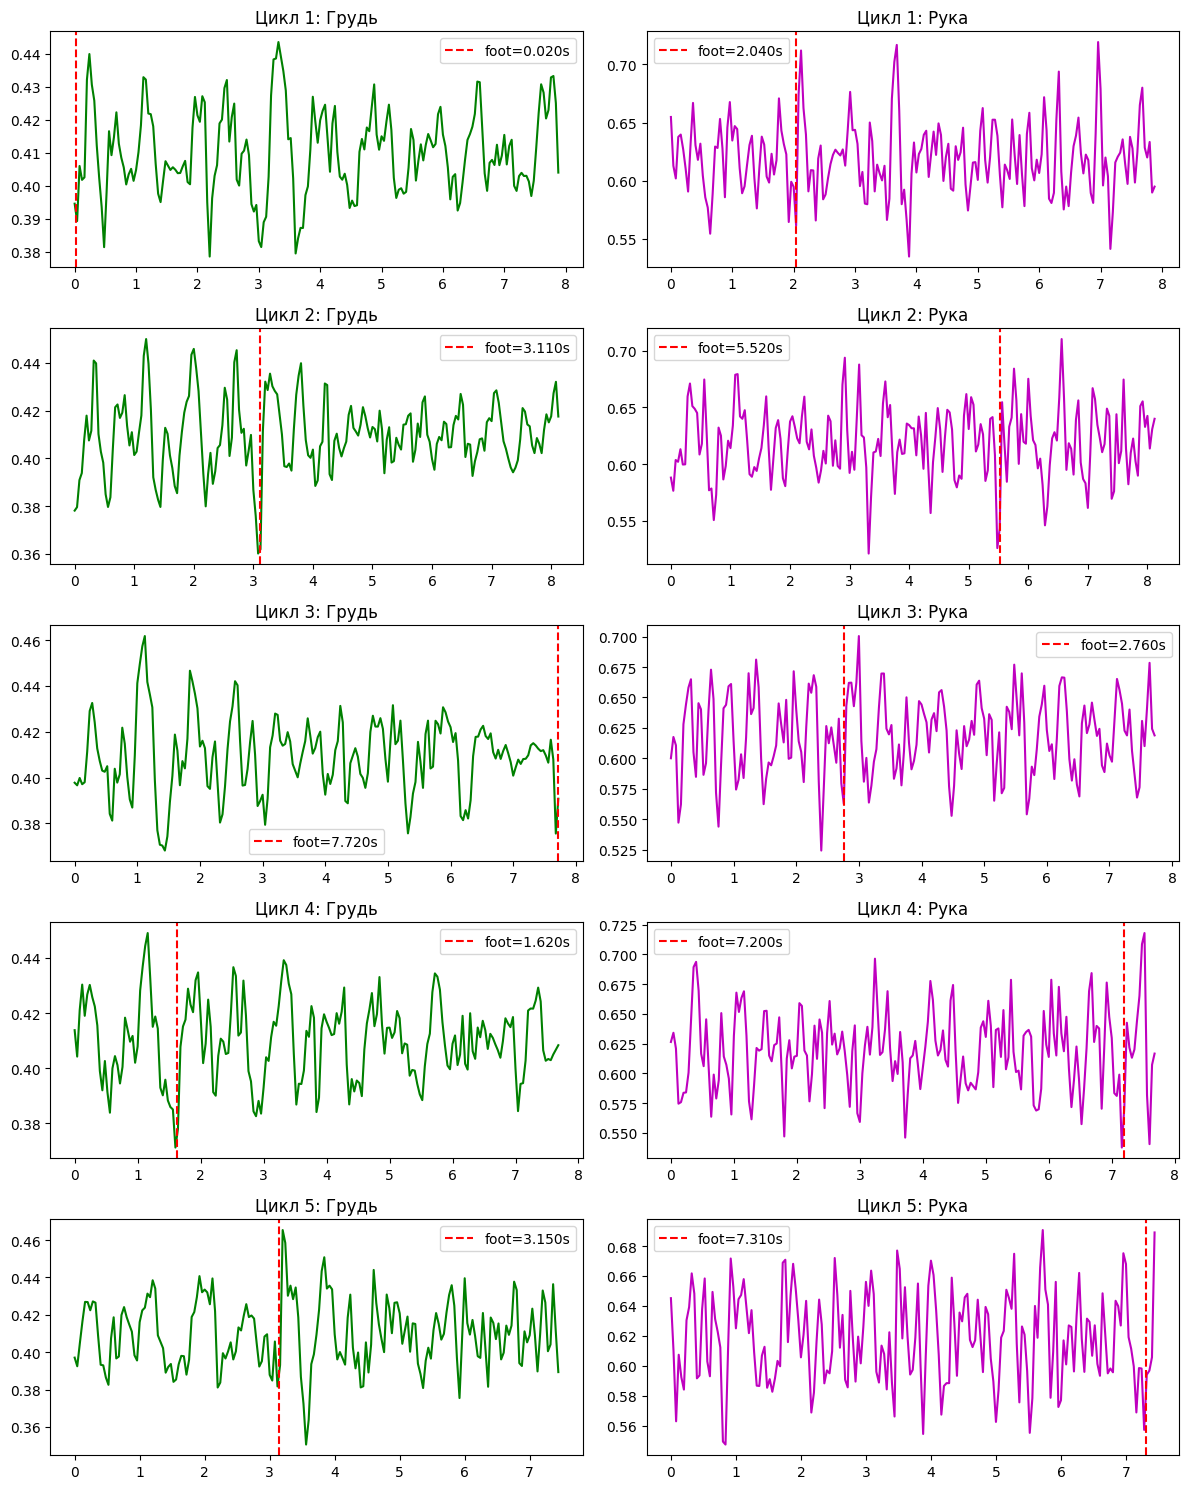

In [ ]:
# Визуализация первых N циклов с отмеченными ногами
N_show = min(5, len(rpeaks)-1)
fig, axes = plt.subplots(N_show, 2, figsize=(12, 3*N_show))
for i, ax_row in enumerate(axes):
    r_curr = rpeaks[i]
    r_next = rpeaks[i+1]
    chest_seg = ppg_chest[r_curr:r_next]
    arm_seg   = ppg_arm[r_curr:r_next]
    t_chest = np.arange(len(chest_seg)) / fs
    t_arm   = np.arange(len(arm_seg)) / fs

    # Грудной канал
    ax_row[0].plot(t_chest, chest_seg, 'g-')
    foot_c = find_foot_in_segment(chest_seg, fs)
    if foot_c is not None:
        ax_row[0].axvline(foot_c/fs, color='red', linestyle='--', label=f'foot={foot_c/fs:.3f}s')
    ax_row[0].set_title(f'Цикл {i+1}: Грудь')
    ax_row[0].legend()

    # Ручной канал
    ax_row[1].plot(t_arm, arm_seg, 'm-')
    foot_a = find_foot_in_segment(arm_seg, fs)
    if foot_a is not None:
        ax_row[1].axvline(foot_a/fs, color='red', linestyle='--', label=f'foot={foot_a/fs:.3f}s')
    ax_row[1].set_title(f'Цикл {i+1}: Рука')
    ax_row[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
def median_smooth(values, window=5, outlier_thresh_ms=30):
    if len(values) < window:
        return values
    smoothed = []
    for i in range(len(values)):
        start = max(0, i - window//2)
        end = min(len(values), i + window//2 + 1)
        med = np.median(values[start:end])
        if abs(values[i] - med) * 1000 < outlier_thresh_ms:
            smoothed.append(values[i])
    return smoothed

ptt_clean = median_smooth(ptt_values, window=5, outlier_thresh_ms=30)
print(f"После фильтрации выбросов: {len(ptt_clean)}")


После фильтрации выбросов: 0


8. Расчёт СРПВ и визуализация PTT

In [ ]:
if len(ptt_clean) >= 5:
    ptt_mean = np.mean(ptt_clean)
    ptt_std  = np.std(ptt_clean)
    print(f"PTT = {ptt_mean*1000:.1f} ± {ptt_std*1000:.1f} мс")

    DISTANCE = 0.8   # метры – уточните под свою установку
    pwv = DISTANCE / ptt_mean
    print(f"СРПВ = {pwv:.2f} м/с")

    plt.figure(figsize=(10,4))
    plt.plot(np.array(ptt_values)*1000, 'o-', alpha=0.5, label='Все PTT')
    plt.plot(np.array(ptt_clean)*1000, 'x-', label='После фильтрации')
    plt.ylabel('PTT, мс')
    plt.xlabel('Номер цикла')
    plt.legend(); plt.grid(True)
    plt.title('Динамика PTT по кардиоциклам')
    plt.show()
else:
    print("Недостаточно надёжных PTT — проверьте сигнал или параметры детекции.")


Недостаточно надёжных PTT — проверьте сигнал или параметры детекции.




---
СЛЕДУЮЩИЙ ВАРИАНТ


---

Метод пересекающихся касательных (Intersecting Tangents Method).



In [2]:
# ============================================================
# ПАЙПЛАЙН: от сырых данных до дифференциального PTT (версия FINAL)
# ============================================================

import numpy as np
import pandas as pd
from scipy.signal import butter, filtfilt, find_peaks, savgol_filter, medfilt, argrelextrema
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# ── 1. Загрузка данных ─────────────────────────────────────
df = pd.read_csv('data4ch_0_7.xls', header=None)   # ваш файл
time = df.iloc[:, 0].values
ppg_chest_raw = df.iloc[:, 1].values
ppg_arm_raw   = df.iloc[:, 2].values
ecg_raw       = df.iloc[:, 4].values

fs = 1.0 / np.mean(np.diff(time))
print(f"Частота дискретизации: {fs:.2f} Гц")

# ── 2. Базовые фильтры и нормализация ──────────────────────
def highpass_filter(data, fs, cutoff=0.5, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, cutoff / nyq, btype='high')
    return filtfilt(b, a, data)

def lowpass_filter(data, fs, cutoff=15.0, order=4):
    nyq = 0.5 * fs
    if cutoff / nyq >= 1.0:
        cutoff = 0.99 * nyq
    b, a = butter(order, cutoff / nyq, btype='low')
    return filtfilt(b, a, data)

def bandpass_filter(data, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    if high >= 1.0:
        high = 0.99
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def normalize_zscore(x):
    return (x - x.mean()) / (x.std() + 1e-8)

def normalize_minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

def remove_outliers_median(sig, window=5, thresh_std=4.0):
    local_med = medfilt(sig, kernel_size=window)
    local_std = np.median(np.abs(sig - local_med)) * 1.4826
    outliers = np.abs(sig - local_med) > (thresh_std * local_std + 1e-8)
    cleaned = sig.copy()
    cleaned[outliers] = local_med[outliers]
    return cleaned

# ── 3. Обработка ЭКГ ──────────────────────────────────────
def preprocess_ecg(ecg_raw, fs):
    nyq = 0.5 * fs
    highcut = min(40.0, nyq * 0.99)
    ecg = bandpass_filter(ecg_raw, fs, 0.5, highcut)
    ecg = normalize_zscore(ecg)
    return ecg

ecg = preprocess_ecg(ecg_raw, fs)

# ── 4. Детекция R-пиков с автоинвертированием ─────────────
def detect_r_peaks_tkeo(ecg, fs, min_rr_sec=0.4, threshold_factor=0.6):
    # Автоинвертирование
    pos = np.max(ecg) - np.median(ecg)
    neg = np.median(ecg) - np.min(ecg)
    if neg > pos:
        ecg_proc = -ecg
        inverted = True
    else:
        ecg_proc = ecg
        inverted = False

    tkeo = ecg_proc[1:-1]**2 - ecg_proc[:-2] * ecg_proc[2:]
    tkeo = np.insert(tkeo, 0, 0)
    win = max(3, int(0.05 * fs) | 1)
    tkeo_smooth = savgol_filter(tkeo, window_length=win, polyorder=2)
    threshold = threshold_factor * np.max(tkeo_smooth)
    min_dist = int(min_rr_sec * fs)
    peaks, _ = find_peaks(tkeo_smooth, height=threshold, distance=min_dist)

    # Уточнение на исходном (неинвертированном) сигнале
    half_win = max(1, int(0.03 * fs))
    refined = []
    for p in peaks:
        lo = max(0, p - half_win)
        hi = min(len(ecg), p + half_win + 1)
        if inverted:
            refined.append(lo + np.argmin(ecg[lo:hi]))  # ищем провал
        else:
            refined.append(lo + np.argmax(ecg[lo:hi]))
    return np.array(sorted(set(refined)), dtype=int)

rpeaks = detect_r_peaks_tkeo(ecg, fs, threshold_factor=0.4)
print(f"Найдено R-пиков: {len(rpeaks)}")

# ── 5. Обработка ФПГ ─────────────────────────────────────
def preprocess_ppg(ppg_raw, fs):
    # Удаление выбросов
    ppg_clean = remove_outliers_median(ppg_raw, window=5, thresh_std=4.0)
    # Убираем дыхательный дрейф (highpass 1.0 Гц)
    ppg_hp = highpass_filter(ppg_clean, fs, cutoff=1.0)
    # Сглаживаем низкочастотным фильтром 10 Гц
    ppg_lp = lowpass_filter(ppg_hp, fs, cutoff=10.0)
    # Нормализуем в [0, 1]
    ppg_norm = normalize_minmax(ppg_lp)
    return ppg_norm

ppg_chest = preprocess_ppg(ppg_chest_raw, fs)
ppg_arm   = preprocess_ppg(ppg_arm_raw, fs)

# ── 6. Поиск onsets (ног) методом пересекающихся касательных ─
def find_onsets_tangents(ppg, fs, interp_factor=8):
    if len(ppg) < 5:
        return np.array([], dtype=int)

    t_orig = np.arange(len(ppg)) / fs
    fs_new = fs * interp_factor
    t_new = np.linspace(t_orig[0], t_orig[-1], int(len(ppg) * interp_factor))
    f = interp1d(t_orig, ppg, kind='cubic')
    ppg_hr = f(t_new)

    deriv1 = np.gradient(ppg_hr)
    deriv2 = np.gradient(deriv1)

    candidates = argrelextrema(deriv2, np.greater)[0]
    if len(candidates) == 0:
        return np.array([], dtype=int)

    onsets_hr = []
    for cand in candidates:
        search_win = int(0.15 * fs_new)
        start = max(0, cand - search_win)
        end = cand
        if start >= end:
            continue
        local_min_idx = start + np.argmin(ppg_hr[start:end])

        search_front = min(local_min_idx + int(0.2 * fs_new), len(deriv1) - 1)
        if search_front <= local_min_idx:
            continue
        max_deriv_idx = local_min_idx + np.argmax(deriv1[local_min_idx:search_front])

        slope = deriv1[max_deriv_idx]
        if slope <= 0:
            continue
        y_min = ppg_hr[local_min_idx]
        t_max_deriv = max_deriv_idx / fs_new
        intersection_idx = int((t_max_deriv + (y_min - ppg_hr[max_deriv_idx]) / slope) * fs_new)
        if local_min_idx <= intersection_idx <= max_deriv_idx:
            onsets_hr.append(intersection_idx)

    onsets_hr = np.unique(onsets_hr)
    onsets = np.round(onsets_hr / interp_factor).astype(int)
    onsets = np.clip(onsets, 0, len(ppg) - 1)
    return onsets

onsets_chest = find_onsets_tangents(ppg_chest, fs)
onsets_arm   = find_onsets_tangents(ppg_arm, fs)
print(f"Найдено onsets: грудь {len(onsets_chest)}, рука {len(onsets_arm)}")

# ── 7. Сопоставление R-пик → onset и расчёт PTT ────────────
def match_and_calc_ptt(rpeaks, onsets, fs, delay_range=(0.05, 0.4)):
    ptt_list = []
    for r_peak in rpeaks:
        start_sample = r_peak + int(delay_range[0] * fs)
        end_sample   = r_peak + int(delay_range[1] * fs)
        valid = onsets[(onsets >= start_sample) & (onsets <= end_sample)]
        if len(valid) > 0:
            ptt = (valid[0] - r_peak) / fs
            if 0.005 <= ptt <= 0.200:
                ptt_list.append(ptt)
    return ptt_list

ptt_chest_list = match_and_calc_ptt(rpeaks, onsets_chest, fs)
ptt_arm_list   = match_and_calc_ptt(rpeaks, onsets_arm, fs)

# Дифференциальное PTT
diff_ptt = []
for pc, pa in zip(ptt_chest_list, ptt_arm_list):
    val = pa - pc
    if val > 0.005:
        diff_ptt.append(val)

print(f"Получено пар PTT: {len(diff_ptt)}")
if diff_ptt:
    mean_ptt = np.mean(diff_ptt)
    std_ptt  = np.std(diff_ptt)
    print(f"Дифференциальное PTT = {mean_ptt*1000:.1f} ± {std_ptt*1000:.1f} мс")
    # (СРПВ будет рассчитана позже)
else:
    print("Валидных PTT не найдено.")

Частота дискретизации: 25.00 Гц
Найдено R-пиков: 92
Найдено onsets: грудь 184, рука 113
Получено пар PTT: 0
Валидных PTT не найдено.
